# Stability

In this notebook, I want to investigate the spatio-temporal patterns of stability in individual model runs.

In [3]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Load Data

In [5]:
model_run = "MIZ009"
delta_t = 4 # time step in seconds
output_dir = "../../MITgcm/so_plumes/" + model_run

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # open dataset
    ds = open_mdsdataset(output_dir, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")

## Calculate Buoyancy Frequency

$$ N^2 = -\frac{g}{\rho}\frac{\Delta \rho}{\Delta z}$$

$N^2>0$ stable\
$N^2<0$ instable

In [15]:
ds["CT"] = gsw.CT_from_pt(ds["S"], ds["T"]) # conservative temperature for N2 calculation 
ds["p"] = ds["PH"] + ds["PHrefC"] # sea pressure for N2 calculation

N2, p_mid = gsw.Nsquared(ds.S, ds.CT, ds.p, lat=-59, axis = 1) # shape: (t,z,y,x)

In [30]:
N2_reformated = np.full((49,51,100,50), np.nan) # format so that it fits to coordinate Zp1
N2_reformated[:,1:50,:,:] = N2
ds['N2'] = (['time', 'Zp1', 'YC', 'XC'], N2_reformated)

## Plot

### Individual Grid Cells

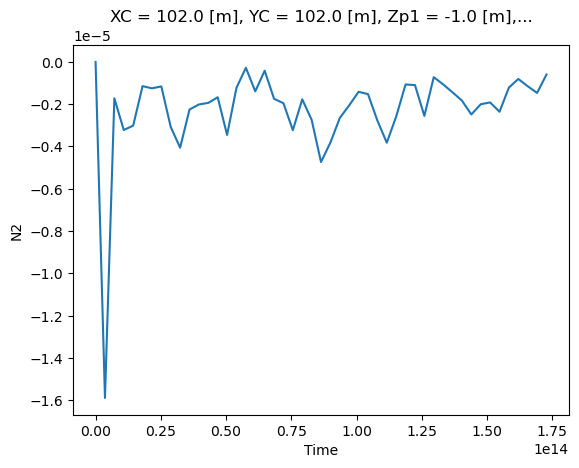

In [40]:
z = 1
x = 25
y = 25

ds.N2.isel(Zp1 = z, XC=x, YC=y).plot()


### Open Water Mean

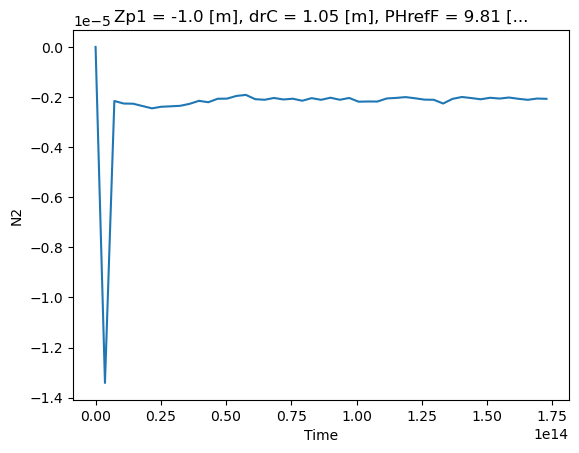

In [44]:
z = 1

ds.N2.isel(Zp1 = z, YC=slice(1,50)).mean(dim = ["XC","YC"]).plot()

### Surface Animation - not working

In [37]:
# make surface animation - somehow this does not work :(
animation = False
if animation:
    fig = surface_animation(ds.isel(Zp1 = 0), var='N2', model_run=model_run, time_dim='time', x_dim='XC', y_dim='YC', colorscale="thermal")
    filename = "surface_animation_" + model_run + "_N2" + ".html"
    fig.write_html(filename)
    # fig.show(renderer="browser") # this works in VScode, but not in Jupyterhub